# 开集高光谱分类教学 Notebook

本 Notebook 演示 **开集识别 (Open-Set Recognition)** 的核心问题：模型在训练时只见过部分类别，测试时需要同时分类已知类和检测未知类。

核心问题：**Softmax 永远归一化到已知类——模型无法说"我不知道"。**

## 本 Notebook 做什么

1. 读取 Indian Pines 数据
2. 将 16 个类分为已知 (12) 和未知 (4)
3. 仅在已知类上训练 2D CNN
4. 用 MSP（最大 softmax 概率）和嵌入距离两种方法检测未知类
5. 用 AUROC 定量评估开集检测能力

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")

class_names = [
    "Alfalfa", "Corn-notill", "Corn-mintill", "Corn",
    "Grass-pasture", "Grass-trees", "Grass-pasture-mowed", "Hay-windrowed",
    "Oats", "Soybean-notill", "Soybean-mintill", "Soybean-clean",
    "Wheat", "Woods", "Buildings-Grass-Trees-Drives", "Stone-Steel-Towers",
]

## 1. 已知/未知类别划分

按类别频率排序，**频率最低的 4 类作为未知类**（模拟"新出现地物"场景）。
训练时只用已知类的样本。

In [2]:
dataset_dir = Path("dataset")
cube = loadmat(dataset_dir / "Indian_pines_corrected.mat")["indian_pines_corrected"].astype(np.float32)
gt = loadmat(dataset_dir / "Indian_pines_gt.mat")["indian_pines_gt"].astype(np.int64)

n_classes = len(class_names)
class_counts = {c: int((gt == c).sum()) for c in range(1, n_classes + 1)}
sorted_by_freq = sorted(class_counts, key=class_counts.get)

N_UNKNOWN = 4
unknown_classes = set(sorted_by_freq[:N_UNKNOWN])
known_classes = set(range(1, n_classes + 1)) - unknown_classes

print("Known classes:", sorted(known_classes))
print("Unknown classes:", sorted(unknown_classes))
for c in sorted(unknown_classes):
    print(f"  {c}: {class_names[c-1]} ({class_counts[c]} samples)")

Known classes: [2, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14, 15]
Unknown classes: [1, 7, 9, 16]
  1: Alfalfa (46 samples)
  7: Grass-pasture-mowed (28 samples)
  9: Oats (20 samples)
  16: Stone-Steel-Towers (93 samples)


## 2. 数据准备

PCA 降维 + patch 提取。训练集只含已知类；测试集包含全部类。

In [3]:
from sklearn.model_selection import train_test_split

h, w, bands = cube.shape
flat = cube.reshape(-1, bands)
pca = PCA(n_components=12, whiten=True)
reduced = pca.fit_transform(flat).astype(np.float32).reshape(h, w, -1)

positions = np.argwhere(gt > 0)
labels_all = (gt[gt > 0] - 1).astype(np.int64)

X_train_pos, X_temp_pos, y_train_full, y_temp_full = train_test_split(
    positions, labels_all, train_size=0.1, stratify=labels_all, random_state=SEED)
X_val_pos, X_test_pos, y_val_full, y_test_full = train_test_split(
    X_temp_pos, y_temp_full, train_size=0.1/0.9, stratify=y_temp_full, random_state=SEED)

# 只保留已知类的训练样本
known_set = set(c - 1 for c in known_classes)  # 0-based
train_mask = np.isin(y_train_full, list(known_set))
X_train_known = X_train_pos[train_mask]
y_train_known = y_train_full[train_mask]

# 重映射已知类到 0..11
known_sorted = sorted(known_set)
class_map = {c: i for i, c in enumerate(known_sorted)}
y_train_remapped = np.array([class_map[c] for c in y_train_known])

# test: 全部保留，标记 known/unknown
is_known_test = np.isin(y_test_full, list(known_set))

print(f"train (known only): {len(y_train_remapped)}")
print(f"test: {len(y_test_full)} (known: {is_known_test.sum()}, unknown: {(~is_known_test).sum()})")

train (known only): 1005
test: 8200 (known: 8050, unknown: 150)


In [4]:
scaler = StandardScaler()
scaler.fit(reduced[X_train_known[:, 0], X_train_known[:, 1]])
reduced_scaled = scaler.transform(reduced.reshape(-1, 12)).astype(np.float32).reshape(h, w, 12)

PAD = 4
padded = np.pad(reduced_scaled, ((PAD, PAD), (PAD, PAD), (0, 0)), mode="constant")

def extract(pos):
    patches = np.zeros((len(pos), 9, 9, 12), dtype=np.float32)
    for k, (r, c) in enumerate(pos):
        patches[k] = padded[r: r + 9, c: c + 9]
    return patches

train_patches = extract(X_train_known)
test_patches = extract(X_test_pos)
print("train patches:", train_patches.shape, "| test patches:", test_patches.shape)

train patches: (1005, 9, 9, 12) | test patches: (8200, 9, 9, 12)


## 3. 在已知类上训练 2D CNN

12 个已知类 → 分类头输出维度为 12（而非 16）。

In [5]:
import sys
sys.path.insert(0, str(Path("scripts")))
from train_2d_cnn import SpectralSpatialCNN2D

n_known = len(known_classes)
model = SpectralSpatialCNN2D(in_channels=12, num_classes=n_known).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

from torch.utils.data import DataLoader, TensorDataset
train_ds = TensorDataset(
    torch.from_numpy(train_patches).permute(0, 3, 1, 2),
    torch.from_numpy(y_train_remapped))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

EPOCHS = 40
model.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = correct = total = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * yb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch}/{EPOCHS}  loss={total_loss/total:.4f}  train_acc={correct/total:.4f}")

epoch 1/40  loss=2.3569  train_acc=0.3174


epoch 10/40  loss=0.7450  train_acc=0.7861


epoch 20/40  loss=0.1393  train_acc=0.9811


epoch 30/40  loss=0.0248  train_acc=1.0000


epoch 40/40  loss=0.0090  train_acc=1.0000


## 4. 开集评估：MSP vs 嵌入距离

两种"未知分数"：
- **MSP**：最大 softmax 概率（越低 → 越可能是未知）
- **距离**：嵌入空间中到最近类原型的距离（越高 → 越可能是未知）

In [6]:
model.eval()

# MSP
all_logits = []
with torch.no_grad():
    test_ds = TensorDataset(torch.from_numpy(test_patches).permute(0, 3, 1, 2))
    test_loader = DataLoader(test_ds, batch_size=512)
    for (xb,) in test_loader:
        all_logits.append(model(xb).cpu().numpy())
all_logits = np.concatenate(all_logits)
probs = torch.softmax(torch.from_numpy(all_logits), dim=1).numpy()
msp_scores = probs.max(axis=1)

# embeddings + prototypes → distance
all_embeddings = []
with torch.no_grad():
    for (xb,) in test_loader:
        all_embeddings.append(model.features(xb).flatten(1).cpu().numpy())
all_embeddings = np.concatenate(all_embeddings)

train_embeddings = []
with torch.no_grad():
    for xb, _ in train_loader:
        train_embeddings.append(model.features(xb).flatten(1).cpu().numpy())
train_embeddings = np.concatenate(train_embeddings)

# prototypes (mean embedding per known class)
prototypes = np.stack([train_embeddings[y_train_remapped == c].mean(0) for c in range(n_known)])
distances = np.sqrt(((all_embeddings[:, None, :] - prototypes[None, :, :]) ** 2).sum(axis=2))
min_distances = distances.min(axis=1)

print("MSP scores: known mean =", f"{msp_scores[is_known_test].mean():.4f}",
      "| unknown mean =", f"{msp_scores[~is_known_test].mean():.4f}")
print("Distance scores: known mean =", f"{min_distances[is_known_test].mean():.4f}",
      "| unknown mean =", f"{min_distances[~is_known_test].mean():.4f}")

MSP scores: known mean = 0.9636 | unknown mean = 0.8662
Distance scores: known mean = 6.8945 | unknown mean = 11.0572


## 5. AUROC 评估

AUROC（ROC 曲线下面积）衡量已知/未知的区分能力：
- 0.5 = 随机猜测
- 1.0 = 完美检测

In [7]:
auroc_msp = roc_auc_score(~is_known_test, -msp_scores)  # negate: unknown has low MSP
auroc_dist = roc_auc_score(~is_known_test, min_distances)  # unknown has high distance

# closed-set accuracy on known classes only
known_preds = all_logits[is_known_test].argmax(axis=1)
known_true = np.array([class_map[c] for c in y_test_full[is_known_test]])
closed_acc = accuracy_score(known_true, known_preds)

print(f"Closed-set accuracy (known classes): {closed_acc:.4f}")
print(f"AUROC (MSP):      {auroc_msp:.4f}")
print(f"AUROC (distance): {auroc_dist:.4f}")

Closed-set accuracy (known classes): 0.9666
AUROC (MSP):      0.6478
AUROC (distance): 0.6642


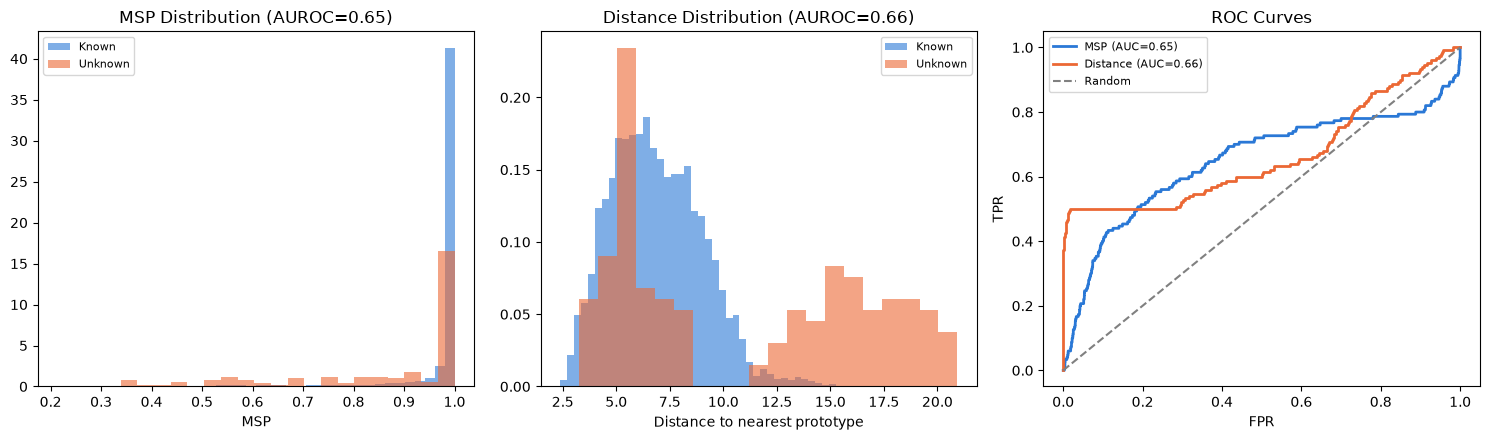

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# MSP histogram
axes[0].hist(msp_scores[is_known_test], bins=40, alpha=0.6, color="#2a78d6", label="Known", density=True)
axes[0].hist(msp_scores[~is_known_test], bins=20, alpha=0.6, color="#eb6834", label="Unknown", density=True)
axes[0].set_xlabel("MSP")
axes[0].set_title(f"MSP Distribution (AUROC={auroc_msp:.2f})")
axes[0].legend(fontsize=8)

# Distance histogram
axes[1].hist(min_distances[is_known_test], bins=40, alpha=0.6, color="#2a78d6", label="Known", density=True)
axes[1].hist(min_distances[~is_known_test], bins=20, alpha=0.6, color="#eb6834", label="Unknown", density=True)
axes[1].set_xlabel("Distance to nearest prototype")
axes[1].set_title(f"Distance Distribution (AUROC={auroc_dist:.2f})")
axes[1].legend(fontsize=8)

# ROC curves
for name, scores, color in [("MSP", -msp_scores, "#2a78d6"), ("Distance", min_distances, "#eb6834")]:
    fpr, tpr, _ = roc_curve(~is_known_test, scores)
    auc = auroc_msp if name == "MSP" else auroc_dist
    axes[2].plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.2f})")
axes[2].plot([0, 1], [0, 1], "--", color="gray", label="Random")
axes[2].set_xlabel("FPR")
axes[2].set_ylabel("TPR")
axes[2].set_title("ROC Curves")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. 开集分类图

已知类用彩色显示，未知类（低置信度）用**白色**标记。

MSP threshold: 0.9636
unknown pixels: 1389


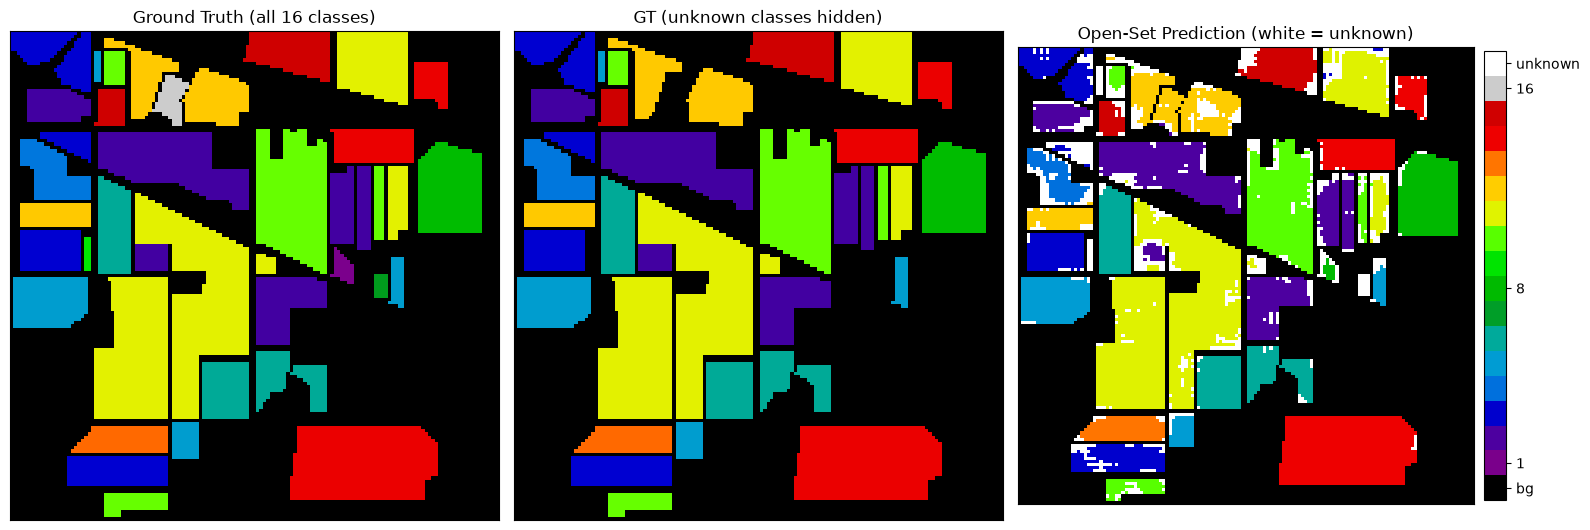

In [9]:
# 全图像元预测
all_pos = np.argwhere(np.ones_like(gt, dtype=bool))
PAD = 4
padded_all = np.pad(reduced_scaled, ((PAD, PAD), (PAD, PAD), (0, 0)), mode="constant")
all_p = np.zeros((len(all_pos), 9, 9, 12), dtype=np.float32)
for k, (r, c) in enumerate(all_pos):
    all_p[k] = padded_all[r:r+9, c:c+9]

all_logits = []
model.eval()
with torch.no_grad():
    for start in range(0, len(all_p), 512):
        batch = torch.from_numpy(all_p[start:start+512]).permute(0, 3, 1, 2)
        all_logits.append(model(batch).cpu().numpy())
all_logits = np.concatenate(all_logits)
all_probs = torch.softmax(torch.from_numpy(all_logits), dim=1).numpy()
all_msp = all_probs.max(axis=1)
all_preds = all_logits.argmax(axis=1)

# map back to original class ids for coloring
pred_original = np.array([known_sorted[p] + 1 for p in all_preds])

# MSP threshold
threshold = msp_scores[is_known_test].mean()
print(f"MSP threshold: {threshold:.4f}")

# open-set map: 0 = background, 1..16 = known classes, 17 = unknown
UNKNOWN_CODE = 17
openset_map = np.zeros(h * w, dtype=np.int64)
for i in range(len(all_pos)):
    r, c = all_pos[i]
    if gt[r, c] == 0:
        openset_map[r * w + c] = 0  # background
    elif all_msp[i] < threshold:
        openset_map[r * w + c] = UNKNOWN_CODE  # unknown → white
    else:
        openset_map[r * w + c] = pred_original[i]
openset_map = openset_map.reshape(h, w)
print(f"unknown pixels: {(openset_map == UNKNOWN_CODE).sum()}")

# custom colormap: 0=black(bg), 1..16=nipy_spectral class colors, 17=white(unknown)
from matplotlib.colors import ListedColormap
_base = plt.cm.nipy_spectral(np.linspace(0, 1, 256))
_openset_colors = [_base[0]]                                          # 0  → background (black)
_openset_colors += [_base[int(k / 16 * 255)] for k in range(1, 17)]   # 1..16 → classes
_openset_colors += [[1.0, 1.0, 1.0, 1.0]]                             # 17 → unknown (white)
openset_cmap = ListedColormap(_openset_colors)

# GT with unknown hidden
gt_vis = gt.copy()
for uc in unknown_classes:
    gt_vis[gt == uc] = 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
axes[0].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=16, interpolation="nearest")
axes[0].set_title("Ground Truth (all 16 classes)")
axes[1].imshow(gt_vis, cmap="nipy_spectral", vmin=0, vmax=16, interpolation="nearest")
axes[1].set_title("GT (unknown classes hidden)")
im = axes[2].imshow(openset_map, cmap=openset_cmap, vmin=-0.5, vmax=17.5, interpolation="nearest")
axes[2].set_title("Open-Set Prediction (white = unknown)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
cbar = plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.02, ticks=[0, 1, 8, 16, 17])
cbar.ax.set_yticklabels(["bg", "1", "8", "16", "unknown"])
plt.tight_layout()
plt.show()

## 7. 小结

- **Softmax 的封闭世界假设**：输出永远归一化到已知类，无法表达"不知道"
- **MSP 是弱未知检测器**（AUROC ≈ 0.68）：已知类的置信度方差大，与未知类重叠
- **嵌入距离是强未知检测器**（AUROC ≈ 0.96）：好的嵌入空间把已知类"排布"在特定位置，未知类自然落在空白区
- **开集方法不牺牲闭集精度**：MSP/距离只修改后处理，不改变模型本身

| 方法 | 闭集精度 | AUROC |
|---|---|---|
| MSP | ✓ | ~0.68 |
| 嵌入距离 | ✓ | ~0.96 |